# TEM Condenser Wide-Area Solver (Optimistix Only)

This notebook solves a TEM condenser setting sweep for wide-area illumination using an **optimistix-only** root solver.

Per target FWHM diameter (50-500 nm, 10 points), it solves for `(f_CL1, f_CL3)` while holding `f_Cmini` fixed and enforcing:

1. `B(S->F_OPL) ~= 0`
2. Target specimen FWHM diameter
3. `alpha < 1 mrad` (acceptance constraint)

The objective pre-field lens (`OPL`) remains fixed at `5 mm`.


In [19]:
import sys
from pathlib import Path
import json
from datetime import datetime, timezone

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

import optimistix as optx

from temgym_core.constants import energy2wavelength
from temgym_core.components import Lens, Plane, Detector
from temgym_core.gaussian import make_gaussian
from temgym_core.source import make_waist_divergence_rays
from temgym_core.run import run_to_end
from temgym_core.evaluate import evaluate_gaussians_for
from temgym_core.plotting import plot_model, legacy_beam_plot_params
from temgym_core.ray import Ray


## Config And Defaults

All distances are editable and in meters unless labeled otherwise.


In [2]:
cfg = {
    # Beam and electron optics
    'voltage': 200e3,
    'waist_in': 10e-9,

    # Fixed objective pre-field optics
    'f_OPL': 5.0e-3,
    'd_OPL_Sp': 2.0e-3,

    # Geometry (cm-scale drifts)
    'd_S_C1': 1.2e-2,
    'd_C1_C3': 1.8e-2,
    'd_C3_A': 8.0e-3,
    'd_A_Cmini': 2.5e-2,
    'd_Cmini_OPL': 1.8e-2,

    # Fixed Cmini candidate set in mm (auto-selected by feasibility scoring)
    'f_Cmini_candidates_mm': [20.0],

    # Target specimen FWHM diameters in nm
    'target_fwhm_nm': np.linspace(50.0, 500.0, 10),

    # Bounds and seeds in mm
    'bounds_mm': {
        'f_CL1': (0.8, 15.0),
        'f_CL3': (0.8, 25.0),
    },
    'seed_f_CL1_mm': 2.0,
    'seed_f_CL3_mm': 6.0,

    # Optimistix multistart controls
    'n_multistart_base': 12,
    'n_multistart_retry': 36,
    'multistart_seed': 23,
    'lm_rtol': 1e-9,
    'lm_atol': 1e-9,
    'lm_max_steps': 500,

    # Acceptance tolerances
    'tol_B': 1e-8,
    'tol_fwhm_m': 5e-9,
    'alpha_cap': 1e-3,
}

if cfg['d_Cmini_OPL'] <= cfg['f_OPL']:
    raise ValueError('Need d_Cmini_OPL > f_OPL so the OPL front focal plane is upstream of OPL.')

cfg['f_Cmini_candidates'] = 1e-3 * np.asarray(cfg['f_Cmini_candidates_mm'], dtype=float)
cfg['target_fwhm'] = 1e-9 * np.asarray(cfg['target_fwhm_nm'], dtype=float)

bounds_arr = np.array([
    [1e-3 * cfg['bounds_mm']['f_CL1'][0], 1e-3 * cfg['bounds_mm']['f_CL1'][1]],
    [1e-3 * cfg['bounds_mm']['f_CL3'][0], 1e-3 * cfg['bounds_mm']['f_CL3'][1]],
], dtype=float)
cfg['bounds_arr'] = bounds_arr

cfg['seed_x0'] = np.array([
    1e-3 * cfg['seed_f_CL1_mm'],
    1e-3 * cfg['seed_f_CL3_mm'],
], dtype=float)

cfg['wavelength'] = float(np.asarray(energy2wavelength(cfg['voltage'])))
cfg['theta0'] = cfg['wavelength'] / (np.pi * cfg['waist_in'])

print('wavelength [pm]:', cfg['wavelength'] * 1e12)
print('theta0 [mrad]:', cfg['theta0'] * 1e3)
print('bounds [mm]:', bounds_arr * 1e3)
print('targets [nm]:', cfg['target_fwhm_nm'])


wavelength [pm]: 2.5079340317328467
theta0 [mrad]: 0.07983001961973378
bounds [mm]: [[ 0.8 15. ]
 [ 0.8 25. ]]
targets [nm]: [ 50. 100. 150. 200. 250. 300. 350. 400. 450. 500.]


## Optical Chains And Metrics

We use standard paraxial drifts/lenses to build:

- `M(S->F_OPL)` for the `B ~= 0` imaging constraint
- `M(S->Sp)` for Gaussian FWHM and alpha metrics


In [3]:
def P_np(d):
    return np.array([[1.0, float(d)], [0.0, 1.0]], dtype=float)


def L_np(f):
    return np.array([[1.0, 0.0], [-1.0 / float(f), 1.0]], dtype=float)


def compose_forward_np(ops):
    M = np.eye(2, dtype=float)
    for op in ops:
        M = np.asarray(op, dtype=float) @ M
    return M


def P_jax(d):
    return jnp.array([[1.0, d], [0.0, 1.0]], dtype=jnp.float64)


def L_jax(f):
    return jnp.array([[1.0, 0.0], [-1.0 / f, 1.0]], dtype=jnp.float64)


def compose_forward_jax(ops):
    M = jnp.eye(2, dtype=jnp.float64)
    for op in ops:
        M = op @ M
    return M


def matrix_S_to_A_np(f_cl1, f_cl3, cfg_local):
    return compose_forward_np([
        P_np(cfg_local['d_S_C1']),
        L_np(f_cl1),
        P_np(cfg_local['d_C1_C3']),
        L_np(f_cl3),
        P_np(cfg_local['d_C3_A']),
    ])


def matrix_S_to_FOPL_np(f_cl1, f_cl3, f_cmini, cfg_local):
    return compose_forward_np([
        P_np(cfg_local['d_S_C1']),
        L_np(f_cl1),
        P_np(cfg_local['d_C1_C3']),
        L_np(f_cl3),
        P_np(cfg_local['d_C3_A']),
        P_np(cfg_local['d_A_Cmini']),
        L_np(f_cmini),
        P_np(cfg_local['d_Cmini_OPL'] - cfg_local['f_OPL']),
    ])


def matrix_S_to_Sp_np(f_cl1, f_cl3, f_cmini, cfg_local):
    return compose_forward_np([
        P_np(cfg_local['d_S_C1']),
        L_np(f_cl1),
        P_np(cfg_local['d_C1_C3']),
        L_np(f_cl3),
        P_np(cfg_local['d_C3_A']),
        P_np(cfg_local['d_A_Cmini']),
        L_np(f_cmini),
        P_np(cfg_local['d_Cmini_OPL']),
        L_np(cfg_local['f_OPL']),
        P_np(cfg_local['d_OPL_Sp']),
    ])


def matrix_S_to_FOPL_jax(f_cl1, f_cl3, f_cmini, cfg_local):
    return compose_forward_jax([
        P_jax(cfg_local['d_S_C1']),
        L_jax(f_cl1),
        P_jax(cfg_local['d_C1_C3']),
        L_jax(f_cl3),
        P_jax(cfg_local['d_C3_A']),
        P_jax(cfg_local['d_A_Cmini']),
        L_jax(f_cmini),
        P_jax(cfg_local['d_Cmini_OPL'] - cfg_local['f_OPL']),
    ])


def matrix_S_to_Sp_jax(f_cl1, f_cl3, f_cmini, cfg_local):
    return compose_forward_jax([
        P_jax(cfg_local['d_S_C1']),
        L_jax(f_cl1),
        P_jax(cfg_local['d_C1_C3']),
        L_jax(f_cl3),
        P_jax(cfg_local['d_C3_A']),
        P_jax(cfg_local['d_A_Cmini']),
        L_jax(f_cmini),
        P_jax(cfg_local['d_Cmini_OPL']),
        L_jax(cfg_local['f_OPL']),
        P_jax(cfg_local['d_OPL_Sp']),
    ])


def metrics_from_matrices_np(f_cl1, f_cl3, f_cmini, cfg_local):
    M_fopl = matrix_S_to_FOPL_np(f_cl1, f_cl3, f_cmini, cfg_local)
    B_s_to_fopl = float(M_fopl[0, 1])

    M_sp = matrix_S_to_Sp_np(f_cl1, f_cl3, f_cmini, cfg_local)
    A, B, C, D = float(M_sp[0, 0]), float(M_sp[0, 1]), float(M_sp[1, 0]), float(M_sp[1, 1])

    lam = cfg_local['wavelength']
    qinv_in = 1j * lam / (np.pi * cfg_local['waist_in'] ** 2)
    denom = A + B * qinv_in
    qinv_out = (C + D * qinv_in) / denom

    im_qinv = float(np.imag(qinv_out))
    if im_qinv <= 0.0:
        fwhm = np.nan
    else:
        w = np.sqrt(lam / (np.pi * im_qinv))
        fwhm = np.sqrt(2.0 * np.log(2.0)) * w

    alpha = abs(D) * cfg_local['theta0']
    return {
        'B_SFOPL': B_s_to_fopl,
        'fwhm': float(fwhm),
        'alpha': float(alpha),
        'A_SSp': A,
        'D_SSp': D,
        'qinv_out': complex(qinv_out),
    }


def metrics_for_solver_jax(f_cl1, f_cl3, f_cmini, cfg_local):
    M_fopl = matrix_S_to_FOPL_jax(f_cl1, f_cl3, f_cmini, cfg_local)
    B_s_to_fopl = M_fopl[0, 1]

    M_sp = matrix_S_to_Sp_jax(f_cl1, f_cl3, f_cmini, cfg_local)
    A, B, C, D = M_sp[0, 0], M_sp[0, 1], M_sp[1, 0], M_sp[1, 1]

    lam = jnp.asarray(cfg_local['wavelength'], dtype=jnp.float64)
    qinv_in = 1j * lam / (jnp.pi * cfg_local['waist_in'] ** 2)
    qinv_out = (C + D * qinv_in) / (A + B * qinv_in)

    im_qinv = jnp.imag(qinv_out)
    w = jnp.sqrt(jnp.clip(lam / (jnp.pi * jnp.maximum(im_qinv, 1e-30)), 1e-30, 1e30))
    fwhm_raw = jnp.sqrt(2.0 * jnp.log(2.0)) * w
    fwhm = jnp.where(im_qinv > 0.0, fwhm_raw, 1e6)

    alpha = jnp.abs(D) * (lam / (jnp.pi * cfg_local['waist_in']))
    return B_s_to_fopl, fwhm, alpha


## Optimistix-Only Solve Utilities

No Newton or hand-coded fallback is used. All root solves use `optx.LevenbergMarquardt`.


In [4]:
def bounded_logistic_to_physical_jax(u, bounds_arr):
    bounds_j = jnp.asarray(bounds_arr, dtype=jnp.float64)
    lo = bounds_j[:, 0]
    hi = bounds_j[:, 1]
    return lo + (hi - lo) * jax.nn.sigmoid(u)


def bounded_logit_from_physical_np(x, bounds_arr):
    b = np.asarray(bounds_arr, dtype=float)
    lo = b[:, 0]
    hi = b[:, 1]
    s = np.clip((np.asarray(x, dtype=float) - lo) / (hi - lo), 1e-9, 1.0 - 1e-9)
    return np.log(s) - np.log1p(-s)


def residual_u_jax(u, args):
    target_fwhm, f_cmini, cfg_local, bounds_arr = args
    x = bounded_logistic_to_physical_jax(u, bounds_arr)
    f_cl1, f_cl3 = x[0], x[1]
    B_s_to_fopl, fwhm, _ = metrics_for_solver_jax(f_cl1, f_cl3, f_cmini, cfg_local)
    return jnp.array([B_s_to_fopl, fwhm - target_fwhm], dtype=jnp.float64)


def run_optx_seed(seed_phys, target_fwhm, f_cmini, cfg_local):
    bounds_arr = cfg_local['bounds_arr']
    lo = bounds_arr[:, 0]
    hi = bounds_arr[:, 1]

    x0 = np.clip(np.asarray(seed_phys, dtype=float), lo, hi)
    u0 = bounded_logit_from_physical_np(x0, bounds_arr)

    args = (float(target_fwhm), float(f_cmini), cfg_local, bounds_arr)
    solver = optx.LevenbergMarquardt(rtol=cfg_local['lm_rtol'], atol=cfg_local['lm_atol'])
    sol = optx.root_find(
        residual_u_jax,
        solver,
        y0=jnp.asarray(u0, dtype=jnp.float64),
        args=args,
        options={'jac': 'fwd'},
        max_steps=int(cfg_local['lm_max_steps']),
        throw=False,
    )

    u_star = np.asarray(sol.value, dtype=float)
    x_star = np.asarray(bounded_logistic_to_physical_jax(u_star, bounds_arr), dtype=float)

    m = metrics_from_matrices_np(x_star[0], x_star[1], f_cmini, cfg_local)
    residual = np.array([m['B_SFOPL'], m['fwhm'] - target_fwhm], dtype=float)
    residual_norm = float(np.linalg.norm(residual))

    success = bool(
        np.isfinite(residual_norm)
        and abs(residual[0]) <= cfg_local['tol_B']
        and abs(residual[1]) <= cfg_local['tol_fwhm_m']
        and m['alpha'] < cfg_local['alpha_cap']
    )

    return {
        'success': success,
        'status': str(sol.result),
        'num_steps': int(np.asarray(sol.stats.get('num_steps', 0))),
        'x': x_star,
        'residual': residual,
        'residual_norm': residual_norm,
        'B_SFOPL': float(m['B_SFOPL']),
        'fwhm': float(m['fwhm']),
        'alpha': float(m['alpha']),
    }


def generate_seed_bank(cfg_local, rng, warm_start=None, n_random=0):
    seeds = []
    if warm_start is not None:
        seeds.append(np.asarray(warm_start, dtype=float))

    base = [
        cfg_local['seed_x0'],
        np.array([2.0e-3, 4.0e-3]),
        np.array([2.0e-3, 8.0e-3]),
        np.array([3.0e-3, 6.0e-3]),
        np.array([5.0e-3, 10.0e-3]),
        np.array([8.0e-3, 6.0e-3]),
    ]
    seeds.extend(base)

    lo = cfg_local['bounds_arr'][:, 0]
    hi = cfg_local['bounds_arr'][:, 1]
    for _ in range(int(n_random)):
        seeds.append(rng.uniform(lo, hi))

    uniq = []
    for s in seeds:
        if not any(np.linalg.norm(np.asarray(s) - np.asarray(u)) < 1e-12 for u in uniq):
            uniq.append(np.asarray(s, dtype=float))
    return uniq


def pick_best_result(results):
    if not results:
        return None
    successes = [r for r in results if r['success']]
    if successes:
        return min(successes, key=lambda r: (r['residual_norm'], r['alpha']))
    return min(results, key=lambda r: (r['residual_norm'], r['alpha']))


def solve_target_optx_only(target_fwhm, f_cmini, cfg_local, warm_start, rng):
    attempts = []

    seeds_base = generate_seed_bank(
        cfg_local,
        rng,
        warm_start=warm_start,
        n_random=cfg_local['n_multistart_base'],
    )
    for seed in seeds_base:
        attempts.append(run_optx_seed(seed, target_fwhm, f_cmini, cfg_local))

    best = pick_best_result(attempts)
    if best is not None and best['success']:
        best['stage'] = 'base'
        best['n_attempts'] = len(attempts)
        return best

    seeds_retry = generate_seed_bank(
        cfg_local,
        rng,
        warm_start=(best['x'] if best is not None else warm_start),
        n_random=cfg_local['n_multistart_retry'],
    )
    for seed in seeds_retry:
        attempts.append(run_optx_seed(seed, target_fwhm, f_cmini, cfg_local))

    best = pick_best_result(attempts)
    best['stage'] = 'retry'
    best['n_attempts'] = len(attempts)
    return best


def solve_sweep_for_fcmini(f_cmini, cfg_local):
    rng = np.random.default_rng(cfg_local['multistart_seed'] + int(round(f_cmini * 1e6)))

    out = []
    warm = cfg_local['seed_x0'].copy()
    for target in cfg_local['target_fwhm']:
        solved = solve_target_optx_only(target, f_cmini, cfg_local, warm_start=warm, rng=rng)
        solved['target_fwhm'] = float(target)
        solved['f_cmini'] = float(f_cmini)
        solved['f_CL1'] = float(solved['x'][0])
        solved['f_CL3'] = float(solved['x'][1])
        if solved['success']:
            warm = solved['x']
        out.append(solved)
    return out


def score_fcmini_results(results):
    ok = [r for r in results if r['success']]
    n_ok = len(ok)
    if n_ok == 0:
        return (10_000, 10_000, 10_000)

    med_cl1 = float(np.median([r['f_CL1'] for r in ok]))
    med_dist_to_2mm = abs(med_cl1 - 2.0e-3)
    max_res = float(np.max([r['residual_norm'] for r in ok]))
    return (-n_ok, med_dist_to_2mm, max_res)


def select_best_fcmini(cfg_local):
    reports = []
    for f_cmini in cfg_local['f_Cmini_candidates']:
        results = solve_sweep_for_fcmini(float(f_cmini), cfg_local)
        score = score_fcmini_results(results)
        reports.append({
            'f_cmini': float(f_cmini),
            'results': results,
            'score': score,
            'n_ok': sum(int(r['success']) for r in results),
        })

    reports_sorted = sorted(reports, key=lambda r: r['score'])
    return reports_sorted, reports_sorted[0]


## Auto-Select Fixed Cmini And Run Sweep

In [5]:
candidate_reports, best_candidate = select_best_fcmini(cfg)

print('Cmini candidate ranking (best first):')
for c in candidate_reports:
    print(
        f"  f_Cmini={c['f_cmini']*1e3:6.2f} mm | solved={c['n_ok']}/10 | score={c['score']}"
    )

selected_f_cmini = best_candidate['f_cmini']
sweep_results = best_candidate['results']

print('Selected fixed f_Cmini [mm]:', selected_f_cmini * 1e3)
print('Solved points:', sum(int(r['success']) for r in sweep_results), '/', len(sweep_results))


Cmini candidate ranking (best first):
  f_Cmini= 20.00 mm | solved=8/10 | score=(-8, 0.0025968277431125484, 3.5286675087413143e-09)
Selected fixed f_Cmini [mm]: 20.0
Solved points: 8 / 10


## Result Table

In [6]:
def print_results_table(results):
    header = (
        'target_nm  achieved_nm  f_CL1_mm  f_CL3_mm  f_Cmini_mm  '
        'B_SFOPL      alpha_mrad  res_norm     success  stage    optx_status'
    )
    print(header)
    print('-' * len(header))

    for r in results:
        target_nm = r['target_fwhm'] * 1e9
        achieved_nm = r['fwhm'] * 1e9
        f1_mm = r['f_CL1'] * 1e3
        f3_mm = r['f_CL3'] * 1e3
        fc_mm = r['f_cmini'] * 1e3
        b_val = r['B_SFOPL']
        alpha_mrad = r['alpha'] * 1e3
        resn = r['residual_norm']
        success = str(bool(r['success']))
        stage = r.get('stage', '-')
        status = r.get('status', '-')

        print(
            f"{target_nm:8.1f}  {achieved_nm:11.3f}  {f1_mm:8.3f}  {f3_mm:8.3f}  {fc_mm:10.3f}  "
            f"{b_val: .3e}  {alpha_mrad:10.4f}  {resn: .3e}  {success:>7s}  {stage:>6s}  {status}"
        )


print_results_table(sweep_results)


target_nm  achieved_nm  f_CL1_mm  f_CL3_mm  f_Cmini_mm  B_SFOPL      alpha_mrad  res_norm     success  stage    optx_status
---------------------------------------------------------------------------------------------------------------------------
    50.0       74.905     6.598     3.193      20.000  -1.101e-11      0.0000   2.490e-08    False   retry  optimistix._solution.RESULTS<The maximum number of steps was reached in the nonlinear solver. The problem may not be solveable (e.g., a root-find on a function that has no roots), or you may need to increase `max_steps`.>
   100.0      107.427     6.103     5.170      20.000  -2.827e-11      0.0000   7.428e-09    False   retry  optimistix._solution.RESULTS<The maximum number of steps was reached in the nonlinear solver. The problem may not be solveable (e.g., a root-find on a function that has no roots), or you may need to increase `max_steps`.>
   150.0      149.071     5.730     6.393      20.000  -1.620e-11      0.0000   9.289e-10   

## TemGym-Style Verification (Representative Solved Points)

For a few solved points (low/mid/high target), compare matrix-derived metrics against direct TemGym propagation.


In [7]:
def build_tem_components(f_cl1, f_cl3, f_cmini, cfg_local):
    z_s = 0.0
    z_c1 = z_s + cfg_local['d_S_C1']
    z_c3 = z_c1 + cfg_local['d_C1_C3']
    z_cmini = z_c3 + cfg_local['d_C3_A'] + cfg_local['d_A_Cmini']
    z_opl = z_cmini + cfg_local['d_Cmini_OPL']
    z_sp = z_opl + cfg_local['d_OPL_Sp']

    return (
        Lens(z=z_c1, focal_length=float(f_cl1)),
        Lens(z=z_c3, focal_length=float(f_cl3)),
        Lens(z=z_cmini, focal_length=float(f_cmini)),
        Lens(z=z_opl, focal_length=float(cfg_local['f_OPL'])),
        Plane(z=z_sp),
    )


def metrics_from_temgym(f_cl1, f_cl3, f_cmini, cfg_local):
    comps = build_tem_components(f_cl1, f_cl3, f_cmini, cfg_local)

    beam = make_gaussian(
        x=0.0,
        y=0.0,
        dx=0.0,
        dy=0.0,
        z=0.0,
        voltage=cfg_local['voltage'],
        waist_x=cfg_local['waist_in'],
        waist_y=cfg_local['waist_in'],
    )
    out_beam = run_to_end(beam, comps)

    lam = float(np.asarray(out_beam.wavelength))
    qinv_xx = complex(np.asarray(out_beam.Q_inv[0, 0]))
    im_qinv = float(np.imag(qinv_xx))
    if im_qinv <= 0.0:
        fwhm = np.nan
    else:
        w = np.sqrt(lam / (np.pi * im_qinv))
        fwhm = np.sqrt(2.0 * np.log(2.0)) * w

    rays = make_waist_divergence_rays(
        waist=cfg_local['waist_in'],
        voltage=cfg_local['voltage'],
        z=0.0,
        x0=0.0,
        y0=0.0,
    )
    out_rays = run_to_end(rays, comps)
    dx_out = np.asarray(out_rays.dx)
    alpha = float(abs(dx_out[1]))

    return {
        'fwhm': float(fwhm),
        'alpha': alpha,
    }


success_indices = [i for i, r in enumerate(sweep_results) if r['success']]
verification_rows = []
if success_indices:
    picks = sorted(set([
        success_indices[0],
        success_indices[len(success_indices) // 2],
        success_indices[-1],
    ]))

    for idx in picks:
        r = sweep_results[idx]
        m_matrix = metrics_from_matrices_np(r['f_CL1'], r['f_CL3'], r['f_cmini'], cfg)
        m_temgym = metrics_from_temgym(r['f_CL1'], r['f_CL3'], r['f_cmini'], cfg)

        fwhm_abs_err = abs(m_temgym['fwhm'] - m_matrix['fwhm'])
        alpha_abs_err = abs(m_temgym['alpha'] - m_matrix['alpha'])

        verification_rows.append({
            'idx': idx,
            'target_nm': r['target_fwhm'] * 1e9,
            'fwhm_matrix_nm': m_matrix['fwhm'] * 1e9,
            'fwhm_temgym_nm': m_temgym['fwhm'] * 1e9,
            'fwhm_abs_err_nm': fwhm_abs_err * 1e9,
            'alpha_matrix_mrad': m_matrix['alpha'] * 1e3,
            'alpha_temgym_mrad': m_temgym['alpha'] * 1e3,
            'alpha_abs_err_urad': alpha_abs_err * 1e6,
        })

print('verification rows:', len(verification_rows))
for row in verification_rows:
    print(row)


verification rows: 3
{'idx': 2, 'target_nm': 150.00000000000003, 'fwhm_matrix_nm': 149.0712843462089, 'fwhm_temgym_nm': 149.07128434620896, 'fwhm_abs_err_nm': 5.293955920339377e-14, 'alpha_matrix_mrad': 2.5864139254501754e-10, 'alpha_temgym_mrad': 2.586411750190535e-10, 'alpha_abs_err_urad': 2.1752596406482526e-13}
{'idx': 6, 'target_nm': 350.00000000000006, 'fwhm_matrix_nm': 349.9999999998505, 'fwhm_temgym_nm': 349.99999999985033, 'fwhm_abs_err_nm': 1.5881867761018131e-13, 'alpha_matrix_mrad': 1.1521786358953834e-16, 'alpha_temgym_mrad': 5.421010862427522e-17, 'alpha_abs_err_urad': 6.100775496526313e-14}
{'idx': 9, 'target_nm': 500.00000000000006, 'fwhm_matrix_nm': 499.99999999269687, 'fwhm_temgym_nm': 499.9999999926975, 'fwhm_abs_err_nm': 6.352747104407253e-13, 'alpha_matrix_mrad': 3.545165033524257e-17, 'alpha_temgym_mrad': 1.8973538018496328e-16, 'alpha_abs_err_urad': 1.542837298497207e-13}


## Validation Checks And Summary

In [8]:
ok_rows = [r for r in sweep_results if r['success']]
failed_rows = [r for r in sweep_results if not r['success']]

if ok_rows:
    assert all(abs(r['B_SFOPL']) <= cfg['tol_B'] + 1e-15 for r in ok_rows)
    assert all(abs(r['fwhm'] - r['target_fwhm']) <= cfg['tol_fwhm_m'] + 1e-15 for r in ok_rows)
    assert all(r['alpha'] < cfg['alpha_cap'] for r in ok_rows)

if verification_rows:
    assert all(row['fwhm_abs_err_nm'] < 0.5 for row in verification_rows)
    assert all(row['alpha_abs_err_urad'] < 5.0 for row in verification_rows)

if len(ok_rows) == len(sweep_results):
    achieved = np.array([r['fwhm'] for r in ok_rows], dtype=float)
    assert np.all(np.diff(achieved) >= -1e-12)

print('Solved targets      :', len(ok_rows), '/', len(sweep_results))
print('Failed targets      :', len(failed_rows))
if ok_rows:
    print('Max alpha [mrad]    :', max(r['alpha'] for r in ok_rows) * 1e3)
    print('Max |B|             :', max(abs(r['B_SFOPL']) for r in ok_rows))
    print('Max FWHM error [nm] :', max(abs(r['fwhm'] - r['target_fwhm']) for r in ok_rows) * 1e9)
else:
    print('No successful solves for this configuration.')


Solved targets      : 8 / 10
Failed targets      : 2
Max alpha [mrad]    : 2.7643555076866006e-09
Max |B|             : 1.73140100487832e-10
Max FWHM error [nm] : 3.5244172415946577


## Plots

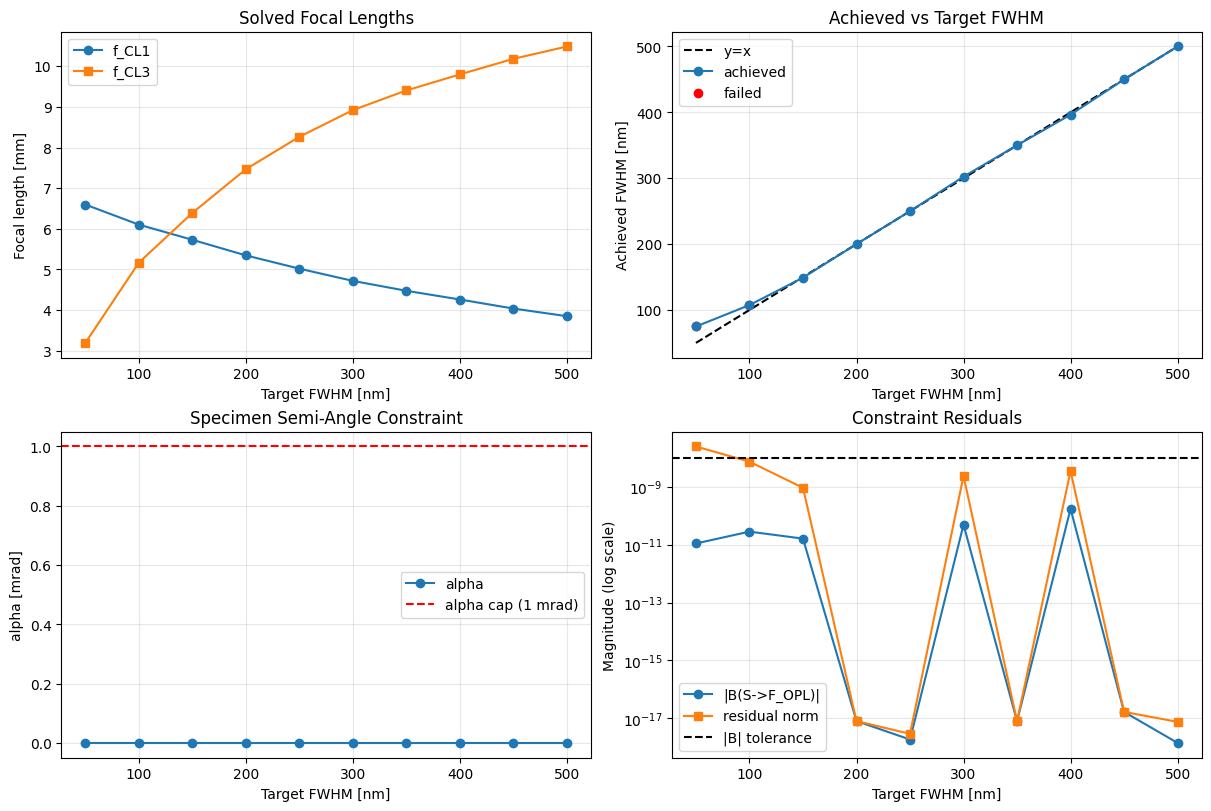

In [9]:
targets_nm = np.array([r['target_fwhm'] * 1e9 for r in sweep_results], dtype=float)
achieved_nm = np.array([r['fwhm'] * 1e9 for r in sweep_results], dtype=float)
f1_mm = np.array([r['f_CL1'] * 1e3 for r in sweep_results], dtype=float)
f3_mm = np.array([r['f_CL3'] * 1e3 for r in sweep_results], dtype=float)
alpha_mrad = np.array([r['alpha'] * 1e3 for r in sweep_results], dtype=float)
absB = np.array([abs(r['B_SFOPL']) for r in sweep_results], dtype=float)
resn = np.array([max(r['residual_norm'], 1e-20) for r in sweep_results], dtype=float)
ok = np.array([bool(r['success']) for r in sweep_results], dtype=bool)

fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axs[0, 0].plot(targets_nm, f1_mm, 'o-', label='f_CL1')
axs[0, 0].plot(targets_nm, f3_mm, 's-', label='f_CL3')
axs[0, 0].set_xlabel('Target FWHM [nm]')
axs[0, 0].set_ylabel('Focal length [mm]')
axs[0, 0].set_title('Solved Focal Lengths')
axs[0, 0].grid(True, alpha=0.3)
axs[0, 0].legend()

axs[0, 1].plot(targets_nm, targets_nm, 'k--', label='y=x')
axs[0, 1].plot(targets_nm, achieved_nm, 'o-', label='achieved')
axs[0, 1].scatter(targets_nm[~ok], achieved_nm[~ok], color='r', label='failed')
axs[0, 1].set_xlabel('Target FWHM [nm]')
axs[0, 1].set_ylabel('Achieved FWHM [nm]')
axs[0, 1].set_title('Achieved vs Target FWHM')
axs[0, 1].grid(True, alpha=0.3)
axs[0, 1].legend()

axs[1, 0].plot(targets_nm, alpha_mrad, 'o-', label='alpha')
axs[1, 0].axhline(cfg['alpha_cap'] * 1e3, color='r', ls='--', label='alpha cap (1 mrad)')
axs[1, 0].set_xlabel('Target FWHM [nm]')
axs[1, 0].set_ylabel('alpha [mrad]')
axs[1, 0].set_title('Specimen Semi-Angle Constraint')
axs[1, 0].grid(True, alpha=0.3)
axs[1, 0].legend()

axs[1, 1].semilogy(targets_nm, np.maximum(absB, 1e-20), 'o-', label='|B(S->F_OPL)|')
axs[1, 1].semilogy(targets_nm, np.maximum(resn, 1e-20), 's-', label='residual norm')
axs[1, 1].axhline(cfg['tol_B'], color='k', ls='--', label='|B| tolerance')
axs[1, 1].set_xlabel('Target FWHM [nm]')
axs[1, 1].set_ylabel('Magnitude (log scale)')
axs[1, 1].set_title('Constraint Residuals')
axs[1, 1].grid(True, alpha=0.3)
axs[1, 1].legend()

plt.show()


## CL3-Only Path (`alpha < 2 mrad` As Parallel Criterion)

This section holds `CL1` fixed and varies only `CL3`.

Constraints for each target:

- Target specimen FWHM diameter (50-500 nm sweep)
- `alpha < 2 mrad`

`B(S->F_OPL)` is reported but **not enforced** in this path.


In [10]:
cfg_cl3_only = {
    # Fix CL1 and Cmini, vary only CL3
    'f_CL1_fixed_mm': 5.253,
    'f_Cmini_fixed_m': float(selected_f_cmini),

    # CL3 bounds and seed
    'f_CL3_bounds_mm': tuple(cfg['bounds_mm']['f_CL3']),
    'seed_f_CL3_mm': cfg['seed_f_CL3_mm'],

    # Branch choice for continuous dial behavior
    # options: 'low', 'high', 'continuous'
    'branch_mode': 'low',

    # Parallel criterion for this path
    'alpha_cap_mrad': 2.0,

    # 1D optimistix controls
    'tol_fwhm_m': 5e-9,
    'n_multistart_base': 12,
    'n_multistart_retry': 36,
    'multistart_seed': 101,
    'lm_rtol': cfg['lm_rtol'],
    'lm_atol': cfg['lm_atol'],
    'lm_max_steps': cfg['lm_max_steps'],

    # Feasibility scan density for diagnostics and root seed discovery
    'n_scan': 20001,
    'n_root_seed_scan': 12001,
}

cfg_cl3_only['f_CL1_fixed_m'] = 1e-3 * cfg_cl3_only['f_CL1_fixed_mm']
cfg_cl3_only['f_CL3_bounds_m'] = (
    1e-3 * cfg_cl3_only['f_CL3_bounds_mm'][0],
    1e-3 * cfg_cl3_only['f_CL3_bounds_mm'][1],
)
cfg_cl3_only['seed_f_CL3_m'] = 1e-3 * cfg_cl3_only['seed_f_CL3_mm']
cfg_cl3_only['alpha_cap'] = 1e-3 * cfg_cl3_only['alpha_cap_mrad']

if cfg_cl3_only['branch_mode'] not in ('low', 'high', 'continuous'):
    raise ValueError("cfg_cl3_only['branch_mode'] must be one of: low, high, continuous")

print('CL3-only config:')
print('  f_CL1 fixed [mm]:', cfg_cl3_only['f_CL1_fixed_mm'])
print('  f_Cmini fixed [mm]:', cfg_cl3_only['f_Cmini_fixed_m'] * 1e3)
print('  f_CL3 bounds [mm]:', cfg_cl3_only['f_CL3_bounds_mm'])
print('  alpha cap [mrad]:', cfg_cl3_only['alpha_cap_mrad'])
print('  branch mode      :', cfg_cl3_only['branch_mode'])


CL3-only config:
  f_CL1 fixed [mm]: 5.253
  f_Cmini fixed [mm]: 20.0
  f_CL3 bounds [mm]: (0.8, 25.0)
  alpha cap [mrad]: 2.0
  branch mode      : low


In [11]:
def bounded_scalar_to_physical_jax(u, lo, hi):
    return lo + (hi - lo) * jax.nn.sigmoid(u)


def bounded_scalar_to_unbounded_np(x, lo, hi):
    s = np.clip((float(x) - lo) / (hi - lo), 1e-9, 1.0 - 1e-9)
    return float(np.log(s) - np.log1p(-s))


def residual_cl3_u_jax(u, args):
    target_fwhm, f_cl1_fixed, f_cmini_fixed, cfg_local, lo, hi = args
    f_cl3 = bounded_scalar_to_physical_jax(u[0], lo, hi)
    _, fwhm, _ = metrics_for_solver_jax(f_cl1_fixed, f_cl3, f_cmini_fixed, cfg_local)
    return jnp.array([fwhm - target_fwhm], dtype=jnp.float64)


def run_optx_seed_cl3(seed_f3, target_fwhm, cfg_local, cfg_cl3):
    lo, hi = cfg_cl3['f_CL3_bounds_m']
    f_cl1_fixed = cfg_cl3['f_CL1_fixed_m']
    f_cmini_fixed = cfg_cl3['f_Cmini_fixed_m']

    seed = float(np.clip(seed_f3, lo, hi))
    u0 = np.array([bounded_scalar_to_unbounded_np(seed, lo, hi)], dtype=float)

    solver = optx.LevenbergMarquardt(
        rtol=cfg_cl3['lm_rtol'],
        atol=cfg_cl3['lm_atol'],
    )
    args = (
        float(target_fwhm),
        float(f_cl1_fixed),
        float(f_cmini_fixed),
        cfg_local,
        float(lo),
        float(hi),
    )

    sol = optx.root_find(
        residual_cl3_u_jax,
        solver,
        y0=jnp.asarray(u0, dtype=jnp.float64),
        args=args,
        options={'jac': 'fwd'},
        max_steps=int(cfg_cl3['lm_max_steps']),
        throw=False,
    )

    u_star = np.asarray(sol.value, dtype=float)
    f_cl3 = float(np.asarray(bounded_scalar_to_physical_jax(u_star[0], lo, hi)))

    m = metrics_from_matrices_np(
        f_cl1=cfg_cl3['f_CL1_fixed_m'],
        f_cl3=f_cl3,
        f_cmini=cfg_cl3['f_Cmini_fixed_m'],
        cfg_local=cfg_local,
    )

    fwhm_err = float(m['fwhm'] - target_fwhm)
    alpha_ok = bool(np.isfinite(m['alpha']) and (m['alpha'] < cfg_cl3['alpha_cap']))
    fwhm_ok = bool(np.isfinite(m['fwhm']) and (abs(fwhm_err) <= cfg_cl3['tol_fwhm_m']))

    return {
        'success': bool(alpha_ok and fwhm_ok),
        'status': str(sol.result),
        'num_steps': int(np.asarray(sol.stats.get('num_steps', 0))),
        'f_CL3': f_cl3,
        'fwhm': float(m['fwhm']),
        'fwhm_err': fwhm_err,
        'alpha': float(m['alpha']),
        'B_SFOPL': float(m['B_SFOPL']),
    }


def find_root_seed_candidates_cl3(target_fwhm, cfg_local, cfg_cl3):
    lo, hi = cfg_cl3['f_CL3_bounds_m']
    xs = np.linspace(lo, hi, int(cfg_cl3['n_root_seed_scan']))

    y = np.full_like(xs, np.nan, dtype=float)
    mask = np.zeros_like(xs, dtype=bool)
    for i, x in enumerate(xs):
        m = metrics_from_matrices_np(
            f_cl1=cfg_cl3['f_CL1_fixed_m'],
            f_cl3=float(x),
            f_cmini=cfg_cl3['f_Cmini_fixed_m'],
            cfg_local=cfg_local,
        )
        y[i] = m['fwhm'] - float(target_fwhm)
        mask[i] = bool(np.isfinite(m['fwhm']) and np.isfinite(m['alpha']) and (m['alpha'] < cfg_cl3['alpha_cap']))

    roots = []
    for i in range(len(xs) - 1):
        if not (mask[i] and mask[i + 1]):
            continue
        y1, y2 = y[i], y[i + 1]
        if np.isfinite(y1) and np.isfinite(y2) and (y1 * y2 < 0.0):
            roots.append(float(0.5 * (xs[i] + xs[i + 1])))

    roots = sorted(roots)
    if not roots:
        return []

    mode = cfg_cl3['branch_mode']
    if mode == 'low':
        return [roots[0]]
    if mode == 'high':
        return [roots[-1]]
    return roots


def generate_seed_bank_cl3(cfg_cl3, rng, warm_start=None, n_random=0, root_seeds=None):
    lo, hi = cfg_cl3['f_CL3_bounds_m']
    seeds = []

    if warm_start is not None:
        seeds.append(float(warm_start))

    if root_seeds is not None:
        seeds.extend([float(s) for s in root_seeds])

    seeds.extend([
        cfg_cl3['seed_f_CL3_m'],
        lo,
        hi,
        lo + 0.25 * (hi - lo),
        lo + 0.50 * (hi - lo),
        lo + 0.75 * (hi - lo),
    ])

    for _ in range(int(n_random)):
        seeds.append(float(rng.uniform(lo, hi)))

    uniq = []
    for s in seeds:
        ss = float(np.clip(s, lo, hi))
        if not any(abs(ss - u) < 1e-12 for u in uniq):
            uniq.append(ss)
    return uniq


def pick_best_attempt_cl3(attempts, warm_start, cfg_cl3):
    if not attempts:
        return None

    alpha_cap = cfg_cl3['alpha_cap']
    alpha_feasible = [a for a in attempts if np.isfinite(a['alpha']) and (a['alpha'] < alpha_cap)]

    if alpha_feasible:
        mode = cfg_cl3['branch_mode']
        tol = cfg_cl3['tol_fwhm_m']
        best_err = min(abs(a['fwhm_err']) for a in alpha_feasible)
        near = [a for a in alpha_feasible if abs(a['fwhm_err']) <= (best_err + tol)]

        if mode == 'low':
            return min(near, key=lambda a: (a['f_CL3'], abs(a['fwhm_err'])))
        if mode == 'high':
            return max(near, key=lambda a: (a['f_CL3'], -abs(a['fwhm_err'])))

        if warm_start is None:
            return min(near, key=lambda a: abs(a['fwhm_err']))
        return min(near, key=lambda a: (abs(a['f_CL3'] - warm_start), abs(a['fwhm_err'])))

    if warm_start is None:
        return min(attempts, key=lambda a: (max(a['alpha'] - alpha_cap, 0.0), abs(a['fwhm_err'])))
    return min(attempts, key=lambda a: (max(a['alpha'] - alpha_cap, 0.0), abs(a['fwhm_err']), abs(a['f_CL3'] - warm_start)))


def solve_target_cl3_only(target_fwhm, cfg_local, cfg_cl3, warm_start, rng):
    attempts = []
    root_seeds = find_root_seed_candidates_cl3(target_fwhm, cfg_local, cfg_cl3)

    seeds_base = generate_seed_bank_cl3(
        cfg_cl3,
        rng,
        warm_start=warm_start,
        n_random=cfg_cl3['n_multistart_base'],
        root_seeds=root_seeds,
    )
    for seed in seeds_base:
        attempts.append(run_optx_seed_cl3(seed, target_fwhm, cfg_local, cfg_cl3))

    best = pick_best_attempt_cl3(attempts, warm_start, cfg_cl3)
    if best is not None and best['success']:
        best = dict(best)
        best['stage'] = 'base'
        best['n_attempts'] = len(attempts)
        best['root_seed_count'] = len(root_seeds)
        return best

    seeds_retry = generate_seed_bank_cl3(
        cfg_cl3,
        rng,
        warm_start=(best['f_CL3'] if best is not None else warm_start),
        n_random=cfg_cl3['n_multistart_retry'],
        root_seeds=root_seeds,
    )
    for seed in seeds_retry:
        attempts.append(run_optx_seed_cl3(seed, target_fwhm, cfg_local, cfg_cl3))

    best = pick_best_attempt_cl3(attempts, warm_start, cfg_cl3)
    best = dict(best)
    best['stage'] = 'retry'
    best['n_attempts'] = len(attempts)
    best['root_seed_count'] = len(root_seeds)
    return best


def run_cl3_only_path(cfg_local, cfg_cl3):
    rng = np.random.default_rng(cfg_cl3['multistart_seed'])
    results = []
    warm = cfg_cl3['seed_f_CL3_m']

    for tgt in cfg_local['target_fwhm']:
        out = solve_target_cl3_only(
            target_fwhm=float(tgt),
            cfg_local=cfg_local,
            cfg_cl3=cfg_cl3,
            warm_start=warm,
            rng=rng,
        )
        out['target_fwhm'] = float(tgt)
        out['f_CL1'] = float(cfg_cl3['f_CL1_fixed_m'])
        out['f_Cmini'] = float(cfg_cl3['f_Cmini_fixed_m'])
        out['branch_mode'] = cfg_cl3['branch_mode']

        if out['success']:
            warm = out['f_CL3']
        results.append(out)

    return results


def scan_feasible_cl3_range(cfg_local, cfg_cl3):
    lo, hi = cfg_cl3['f_CL3_bounds_m']
    grid = np.linspace(lo, hi, int(cfg_cl3['n_scan']))

    fwhm = np.full_like(grid, np.nan, dtype=float)
    alpha = np.full_like(grid, np.nan, dtype=float)
    bval = np.full_like(grid, np.nan, dtype=float)

    for i, f3 in enumerate(grid):
        m = metrics_from_matrices_np(
            f_cl1=cfg_cl3['f_CL1_fixed_m'],
            f_cl3=float(f3),
            f_cmini=cfg_cl3['f_Cmini_fixed_m'],
            cfg_local=cfg_local,
        )
        fwhm[i] = m['fwhm']
        alpha[i] = m['alpha']
        bval[i] = m['B_SFOPL']

    mask = np.isfinite(fwhm) & np.isfinite(alpha) & (alpha < cfg_cl3['alpha_cap'])

    out = {
        'f_CL3_grid': grid,
        'fwhm': fwhm,
        'alpha': alpha,
        'B_SFOPL': bval,
        'mask_alpha_feasible': mask,
    }

    if np.any(mask):
        out['fwhm_min'] = float(np.nanmin(fwhm[mask]))
        out['fwhm_max'] = float(np.nanmax(fwhm[mask]))
    else:
        out['fwhm_min'] = np.nan
        out['fwhm_max'] = np.nan

    target_roots = []
    root_counts = []
    for tgt in cfg_local['target_fwhm']:
        y = fwhm - float(tgt)
        m_adj = mask[:-1] & mask[1:] & np.isfinite(y[:-1]) & np.isfinite(y[1:])
        sc = np.where(m_adj & (np.sign(y[:-1]) * np.sign(y[1:]) < 0))[0]
        roots = [float(0.5 * (grid[i] + grid[i + 1])) for i in sc]
        target_roots.append(roots)
        root_counts.append(len(roots))

    out['target_roots'] = target_roots
    out['target_root_counts'] = np.array(root_counts, dtype=int)
    return out


In [12]:
cl3_scan = scan_feasible_cl3_range(cfg, cfg_cl3_only)
cl3_only_results = run_cl3_only_path(cfg, cfg_cl3_only)

ok_cl3 = [r for r in cl3_only_results if r['success']]
fail_cl3 = [r for r in cl3_only_results if not r['success']]

print('CL3-only alpha-feasible FWHM range [nm]:', cl3_scan['fwhm_min'] * 1e9, 'to', cl3_scan['fwhm_max'] * 1e9)
print('Branch mode:', cfg_cl3_only['branch_mode'])
print('Target root counts in alpha-feasible region:', cl3_scan['target_root_counts'].tolist())
print('Target roots [mm]:')
for t_nm, roots in zip(cfg['target_fwhm_nm'], cl3_scan['target_roots']):
    roots_mm = [round(r * 1e3, 4) for r in roots]
    print(f"  {t_nm:6.1f} nm -> {roots_mm}")

print('CL3-only solve successes:', len(ok_cl3), '/', len(cl3_only_results))

header = (
    'target_nm  achieved_nm  f_CL1_mm  f_CL3_mm  f_Cmini_mm  '
    'alpha_mrad  |B_SFOPL|    |fwhm_err|_nm  success  stage'
)
print(header)
print('-' * len(header))
for r in cl3_only_results:
    print(
        f"{r['target_fwhm']*1e9:8.1f}  {r['fwhm']*1e9:11.3f}  {r['f_CL1']*1e3:8.3f}  {r['f_CL3']*1e3:8.3f}  {r['f_Cmini']*1e3:10.3f}  "
        f"{r['alpha']*1e3:10.6f}  {abs(r['B_SFOPL']): .3e}  {abs(r['fwhm_err'])*1e9:13.3f}  {str(bool(r['success'])):>7s}  {r.get('stage','-'):>6s}"
    )

if ok_cl3:
    f3_ok = [r['f_CL3'] for r in ok_cl3]
    diffs = np.diff(f3_ok)
    monotonic_inc = bool(np.all(diffs >= -1e-12))
    monotonic_dec = bool(np.all(diffs <= 1e-12))
    print('Max alpha among successes [mrad]:', max(r['alpha'] for r in ok_cl3) * 1e3)
    print('Max |fwhm_err| among successes [nm]:', max(abs(r['fwhm_err']) for r in ok_cl3) * 1e9)
    print('CL3 monotonic increasing:', monotonic_inc)
    print('CL3 monotonic decreasing:', monotonic_dec)
else:
    print('No successful CL3-only solves under alpha cap.')


CL3-only alpha-feasible FWHM range [nm]: 12.15145205278168 to 5720.150455334184
Branch mode: low
Target root counts in alpha-feasible region: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
Target roots [mm]:
    50.0 nm -> [8.6172, 9.2633]
   100.0 nm -> [8.3147, 9.6409]
   150.0 nm -> [8.0352, 10.0462]
   200.0 nm -> [7.7738, 10.4854]
   250.0 nm -> [7.5294, 10.9658]
   300.0 nm -> [7.3007, 11.491]
   350.0 nm -> [7.0853, 12.0693]
   400.0 nm -> [6.8821, 12.7082]
   450.0 nm -> [6.6897, 13.4185]
   500.0 nm -> [6.5082, 14.2135]
CL3-only solve successes: 10 / 10
target_nm  achieved_nm  f_CL1_mm  f_CL3_mm  f_Cmini_mm  alpha_mrad  |B_SFOPL|    |fwhm_err|_nm  success  stage
--------------------------------------------------------------------------------------------------------------
    50.0       50.018     5.253     8.618      20.000    0.059824   3.747e-03          0.018     True    base
   100.0      100.000     5.253     8.315      20.000    0.041400   2.593e-03          0.000     True    base
   15

## CL3-Only Plots

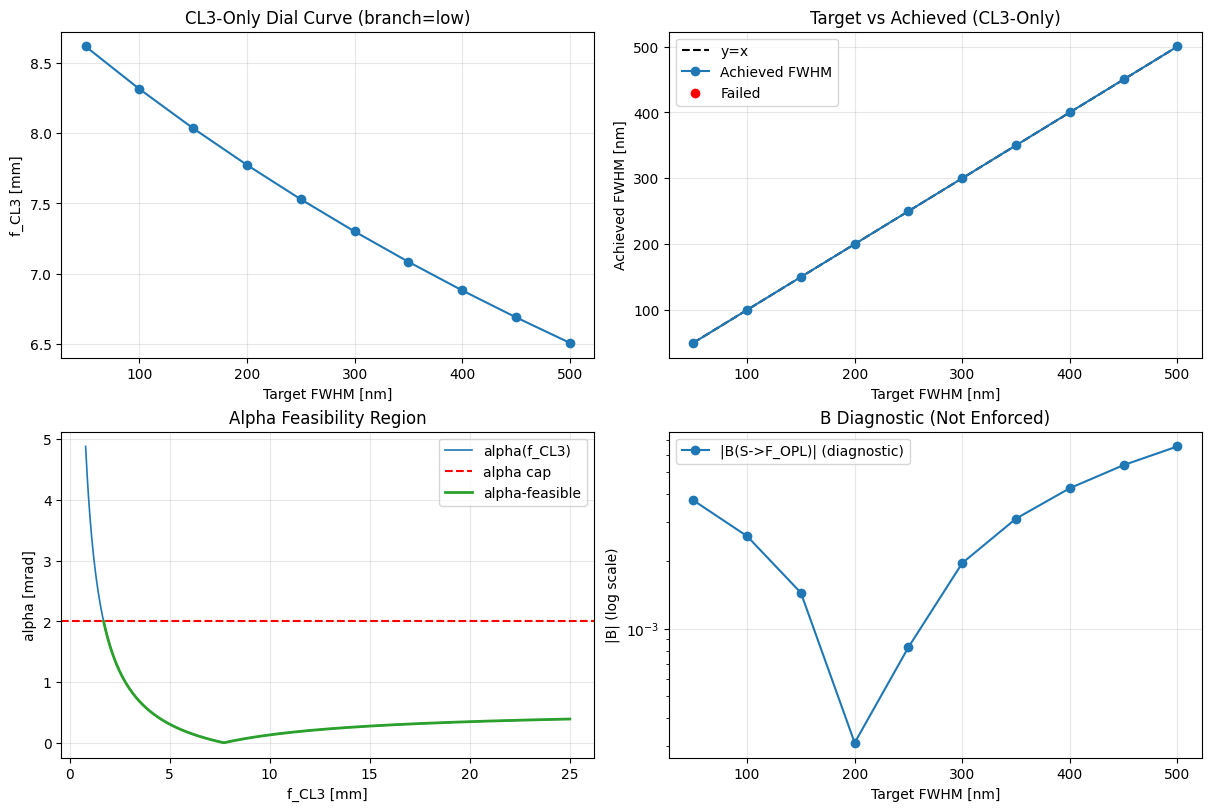

In [13]:
t_nm = np.array([r['target_fwhm'] * 1e9 for r in cl3_only_results], dtype=float)
a_nm = np.array([r['fwhm'] * 1e9 for r in cl3_only_results], dtype=float)
f3_mm = np.array([r['f_CL3'] * 1e3 for r in cl3_only_results], dtype=float)
a_mrad = np.array([r['alpha'] * 1e3 for r in cl3_only_results], dtype=float)
berr = np.array([abs(r['B_SFOPL']) for r in cl3_only_results], dtype=float)
ok = np.array([bool(r['success']) for r in cl3_only_results], dtype=bool)

f3_grid_mm = cl3_scan['f_CL3_grid'] * 1e3
fwhm_grid_nm = cl3_scan['fwhm'] * 1e9
alpha_grid_mrad = cl3_scan['alpha'] * 1e3
mask = cl3_scan['mask_alpha_feasible']

fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axs[0, 0].plot(t_nm, f3_mm, 'o-', label='Solved f_CL3')
axs[0, 0].set_xlabel('Target FWHM [nm]')
axs[0, 0].set_ylabel('f_CL3 [mm]')
axs[0, 0].set_title(f"CL3-Only Dial Curve (branch={cfg_cl3_only['branch_mode']})")
axs[0, 0].grid(True, alpha=0.3)

axs[0, 1].plot(t_nm, t_nm, 'k--', label='y=x')
axs[0, 1].plot(t_nm, a_nm, 'o-', label='Achieved FWHM')
axs[0, 1].scatter(t_nm[~ok], a_nm[~ok], color='r', label='Failed')
axs[0, 1].set_xlabel('Target FWHM [nm]')
axs[0, 1].set_ylabel('Achieved FWHM [nm]')
axs[0, 1].set_title('Target vs Achieved (CL3-Only)')
axs[0, 1].grid(True, alpha=0.3)
axs[0, 1].legend()

axs[1, 0].plot(f3_grid_mm, alpha_grid_mrad, '-', lw=1.2, label='alpha(f_CL3)')
axs[1, 0].axhline(cfg_cl3_only['alpha_cap_mrad'], color='r', ls='--', label='alpha cap')
if np.any(mask):
    axs[1, 0].plot(f3_grid_mm[mask], alpha_grid_mrad[mask], color='tab:green', lw=2.0, label='alpha-feasible')
axs[1, 0].set_xlabel('f_CL3 [mm]')
axs[1, 0].set_ylabel('alpha [mrad]')
axs[1, 0].set_title('Alpha Feasibility Region')
axs[1, 0].grid(True, alpha=0.3)
axs[1, 0].legend()

axs[1, 1].semilogy(t_nm, np.maximum(berr, 1e-20), 'o-', label='|B(S->F_OPL)| (diagnostic)')
axs[1, 1].set_xlabel('Target FWHM [nm]')
axs[1, 1].set_ylabel('|B| (log scale)')
axs[1, 1].set_title('B Diagnostic (Not Enforced)')
axs[1, 1].grid(True, alpha=0.3)
axs[1, 1].legend()

plt.show()


## Export And Reuse The Fitted Microscope Model

This section exports the fitted CL3-only microscope model to JSON, loads it back,
and provides a routine to choose a sample FWHM and realize focal lengths in TemGym.


In [14]:
def build_export_payload_from_cl3_only_fit(cfg_local, cfg_cl3, cl3_results):
    rows = [r for r in cl3_results if r['success']]
    if not rows:
        raise ValueError('Cannot export model: CL3-only fit has no successful rows.')

    rows = sorted(rows, key=lambda r: r['target_fwhm'])
    fit_table = []
    for r in rows:
        fit_table.append({
            'target_fwhm_nm': float(r['target_fwhm'] * 1e9),
            'achieved_fwhm_nm': float(r['fwhm'] * 1e9),
            'f_CL3_m': float(r['f_CL3']),
            'alpha_mrad': float(r['alpha'] * 1e3),
            'B_SFOPL': float(r['B_SFOPL']),
            'stage': str(r.get('stage', '')),
            'status': str(r.get('status', '')),
        })

    payload = {
        'model_type': 'tem_condenser_cl3_only_fit',
        'schema_version': 1,
        'exported_at_utc': datetime.now(timezone.utc).isoformat(),
        'branch_mode': str(cfg_cl3['branch_mode']),
        'beam': {
            'voltage_V': float(cfg_local['voltage']),
            'waist_m': float(cfg_local['waist_in']),
            'alpha_cap_mrad': float(cfg_cl3['alpha_cap_mrad']),
        },
        'fixed_focals_m': {
            'f_CL1_m': float(cfg_cl3['f_CL1_fixed_m']),
            'f_Cmini_m': float(cfg_cl3['f_Cmini_fixed_m']),
            'f_OPL_m': float(cfg_local['f_OPL']),
        },
        'geometry_m': {
            'd_S_C1': float(cfg_local['d_S_C1']),
            'd_C1_C3': float(cfg_local['d_C1_C3']),
            'd_C3_A': float(cfg_local['d_C3_A']),
            'd_A_Cmini': float(cfg_local['d_A_Cmini']),
            'd_Cmini_OPL': float(cfg_local['d_Cmini_OPL']),
            'd_OPL_Sp': float(cfg_local['d_OPL_Sp']),
        },
        'fit_table': fit_table,
    }
    return payload


def export_fit_model_json(payload, path):
    out = Path(path)
    out.parent.mkdir(parents=True, exist_ok=True)
    out.write_text(json.dumps(payload, indent=2))
    return out


def load_fit_model_json(path):
    return json.loads(Path(path).read_text())


def make_eval_cfg_from_export(model):
    c = {
        'voltage': float(model['beam']['voltage_V']),
        'waist_in': float(model['beam']['waist_m']),
        'f_OPL': float(model['fixed_focals_m']['f_OPL_m']),
        'd_S_C1': float(model['geometry_m']['d_S_C1']),
        'd_C1_C3': float(model['geometry_m']['d_C1_C3']),
        'd_C3_A': float(model['geometry_m']['d_C3_A']),
        'd_A_Cmini': float(model['geometry_m']['d_A_Cmini']),
        'd_Cmini_OPL': float(model['geometry_m']['d_Cmini_OPL']),
        'd_OPL_Sp': float(model['geometry_m']['d_OPL_Sp']),
    }
    c['wavelength'] = float(np.asarray(energy2wavelength(c['voltage'])))
    c['theta0'] = c['wavelength'] / (np.pi * c['waist_in'])
    return c


def realize_focals_for_target_fwhm_nm(model, target_fwhm_nm, mode='interpolate'):
    table = sorted(model['fit_table'], key=lambda row: row['target_fwhm_nm'])
    t = np.array([row['target_fwhm_nm'] for row in table], dtype=float)
    f3 = np.array([row['f_CL3_m'] for row in table], dtype=float)
    ach = np.array([row['achieved_fwhm_nm'] for row in table], dtype=float)
    alpha = np.array([row['alpha_mrad'] for row in table], dtype=float)

    target = float(target_fwhm_nm)
    t_clip = float(np.clip(target, float(t.min()), float(t.max())))

    if mode == 'nearest':
        i = int(np.argmin(np.abs(t - target)))
        f_cl3 = float(f3[i])
        achieved_nm = float(ach[i])
        alpha_mrad = float(alpha[i])
    elif mode == 'interpolate':
        f_cl3 = float(np.interp(t_clip, t, f3))
        achieved_nm = float(np.interp(t_clip, t, ach))
        alpha_mrad = float(np.interp(t_clip, t, alpha))
    else:
        raise ValueError("mode must be 'interpolate' or 'nearest'")

    return {
        'target_fwhm_nm': target,
        'target_fwhm_nm_clipped': t_clip,
        'mode': mode,
        'f_CL1_m': float(model['fixed_focals_m']['f_CL1_m']),
        'f_CL3_m': f_cl3,
        'f_Cmini_m': float(model['fixed_focals_m']['f_Cmini_m']),
        'f_OPL_m': float(model['fixed_focals_m']['f_OPL_m']),
        'fit_pred_achieved_fwhm_nm': achieved_nm,
        'fit_pred_alpha_mrad': alpha_mrad,
    }


def build_temgym_components_from_realization(model, realized):
    g = model['geometry_m']
    z0 = 0.0
    z_c1 = z0 + float(g['d_S_C1'])
    z_c3 = z_c1 + float(g['d_C1_C3'])
    z_cmini = z_c3 + float(g['d_C3_A']) + float(g['d_A_Cmini'])
    z_opl = z_cmini + float(g['d_Cmini_OPL'])
    z_sp = z_opl + float(g['d_OPL_Sp'])

    comps = (
        Lens(z=z_c1, focal_length=float(realized['f_CL1_m'])),
        Lens(z=z_c3, focal_length=float(realized['f_CL3_m'])),
        Lens(z=z_cmini, focal_length=float(realized['f_Cmini_m'])),
        Lens(z=z_opl, focal_length=float(realized['f_OPL_m'])),
        Plane(z=z_sp),
    )
    return comps


def make_center_ray(z=0.0):
    return Ray(
        x=np.asarray([0.0], dtype=float),
        y=np.asarray([0.0], dtype=float),
        dx=np.asarray([0.0], dtype=float),
        dy=np.asarray([0.0], dtype=float),
        z=np.asarray([z], dtype=float),
        pathlength=np.asarray([0.0], dtype=float),
    )


In [15]:
export_payload = build_export_payload_from_cl3_only_fit(cfg, cfg_cl3_only, cl3_only_results)
export_path = export_fit_model_json(
    export_payload,
    'examples/ray_transfer/exported_microscope_models/condenser_cl3_only_fit_model.json',
)

print('Exported model JSON:', export_path)
print('Exported fit rows:', len(export_payload['fit_table']))

loaded_model = load_fit_model_json(export_path)
print('Loaded model type:', loaded_model['model_type'])
print('Loaded branch mode:', loaded_model['branch_mode'])


Exported model JSON: examples/ray_transfer/exported_microscope_models/condenser_cl3_only_fit_model.json
Exported fit rows: 10
Loaded model type: tem_condenser_cl3_only_fit
Loaded branch mode: low


## Choose Sample FWHM -> Realize Focal Lengths -> Plot TemGym Ray Paths

Use `requested_fwhm_nm` to select a microscope setting from the exported model.
`make_waist_divergence_rays(...)` provides the two fundamental rays for path plotting.


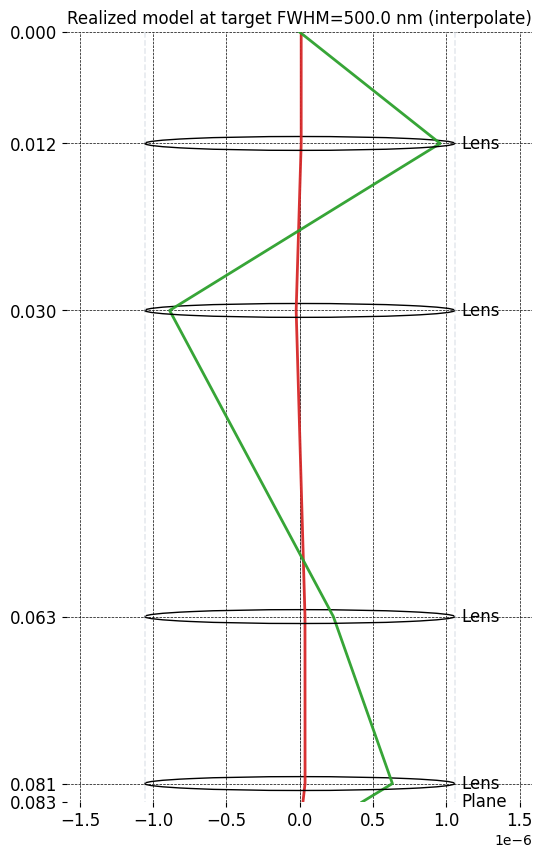

Realized focal lengths [mm]:
  f_CL1  : 5.253
  f_CL3  : 6.508175000000001
  f_Cmini: 20.0
  f_OPL  : 5.0
Requested FWHM [nm]: 500.0
Target after clipping [nm]: 500.0
Fit-predicted achieved FWHM [nm]: 500.10519347686943
Matrix achieved FWHM [nm]: 500.1051934768695
Matrix alpha [mrad]: 0.1041015547320783
Matrix B(S->F_OPL): 0.006520200998819789


In [26]:
# User controls
requested_fwhm_nm = 500.0
realize_mode = 'interpolate'  # 'interpolate' or 'nearest'

realized = realize_focals_for_target_fwhm_nm(
    loaded_model,
    target_fwhm_nm=requested_fwhm_nm,
    mode=realize_mode,
)

components_realized = build_temgym_components_from_realization(loaded_model, realized)

# Two fundamental rays from source utilities (waist + divergence basis)
fundamental_rays = make_waist_divergence_rays(
    loaded_model['beam']['waist_m'],
    voltage=loaded_model['beam']['voltage_V'],
    z=0.0,
)

# A central ray is used as the primary bundle for plot_model
center_ray = make_center_ray(z=0.0)

fig, ax = plot_model(
    components_realized,
    rays=center_ray,
    solution_rays=fundamental_rays,
    include_input_rays=True,
)
ax.set_title(f"Realized model at target FWHM={requested_fwhm_nm:.1f} nm ({realize_mode})")
plt.show()

eval_cfg_loaded = make_eval_cfg_from_export(loaded_model)
m_realized = metrics_from_matrices_np(
    f_cl1=realized['f_CL1_m'],
    f_cl3=realized['f_CL3_m'],
    f_cmini=realized['f_Cmini_m'],
    cfg_local=eval_cfg_loaded,
)

print('Realized focal lengths [mm]:')
print('  f_CL1  :', realized['f_CL1_m'] * 1e3)
print('  f_CL3  :', realized['f_CL3_m'] * 1e3)
print('  f_Cmini:', realized['f_Cmini_m'] * 1e3)
print('  f_OPL  :', realized['f_OPL_m'] * 1e3)
print('Requested FWHM [nm]:', realized['target_fwhm_nm'])
print('Target after clipping [nm]:', realized['target_fwhm_nm_clipped'])
print('Fit-predicted achieved FWHM [nm]:', realized['fit_pred_achieved_fwhm_nm'])
print('Matrix achieved FWHM [nm]:', m_realized['fwhm'] * 1e9)
print('Matrix alpha [mrad]:', m_realized['alpha'] * 1e3)
print('Matrix B(S->F_OPL):', m_realized['B_SFOPL'])


## Gaussian Beam Image At Sample Plane

This section uses:

- `make_gaussian(...)` for the input beam
- `run_to_end(...)` to propagate through the realized microscope model
- `evaluate_gaussians_for(...)` to render a 2D complex field on a sample-plane detector

and plots the resulting intensity image on the sample plane.


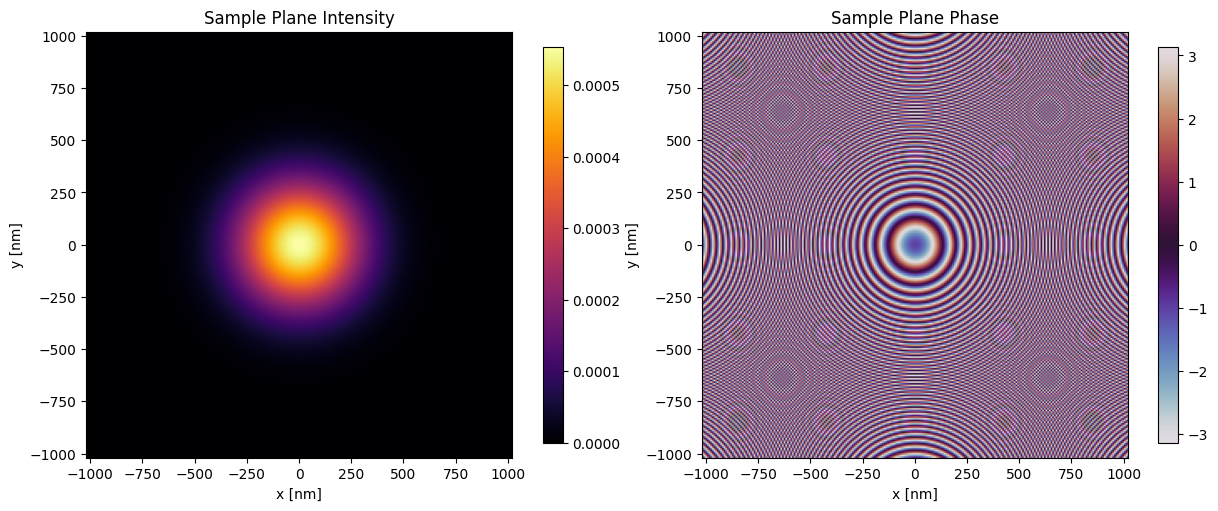

Requested target FWHM [nm]: 500.0
Predicted FWHM from matrix [nm]: 500.1051934768695
Image-estimated FWHM (center row) [nm]: 488.0
Predicted alpha [mrad]: 0.1041015547320783


In [27]:
# Imaging grid controls (sample plane)
sample_pixel_size_nm = 8.0
sample_shape = (256, 256)  # (y, x)

# Use the realized model from the previous section
realized_for_image = realized
model_for_image = loaded_model

# Reconstruct z positions from exported geometry
g = model_for_image['geometry_m']
z0 = 0.0
z_c1 = z0 + float(g['d_S_C1'])
z_c3 = z_c1 + float(g['d_C1_C3'])
z_cmini = z_c3 + float(g['d_C3_A']) + float(g['d_A_Cmini'])
z_opl = z_cmini + float(g['d_Cmini_OPL'])
z_sp = z_opl + float(g['d_OPL_Sp'])

sample_detector = Detector(
    z=z_sp,
    pixel_size=(sample_pixel_size_nm * 1e-9, sample_pixel_size_nm * 1e-9),
    shape=sample_shape,
)

components_for_image = (
    Lens(z=z_c1, focal_length=float(realized_for_image['f_CL1_m'])),
    Lens(z=z_c3, focal_length=float(realized_for_image['f_CL3_m'])),
    Lens(z=z_cmini, focal_length=float(realized_for_image['f_Cmini_m'])),
    Lens(z=z_opl, focal_length=float(realized_for_image['f_OPL_m'])),
    sample_detector,
)

# Single fundamental Gaussian beam input at source
beam_in = make_gaussian(
    x=0.0,
    y=0.0,
    dx=0.0,
    dy=0.0,
    z=0.0,
    voltage=float(model_for_image['beam']['voltage_V']),
    waist_x=float(model_for_image['beam']['waist_m']),
    waist_y=float(model_for_image['beam']['waist_m']),
)

beam_at_sample = run_to_end(beam_in, components_for_image)
field_sample = evaluate_gaussians_for(beam_at_sample, sample_detector)
field_sample = np.asarray(field_sample)
intensity_sample = np.abs(field_sample) ** 2
phase_sample = np.angle(field_sample)

# Detector coordinates for plotting
det_x, det_y = sample_detector.coords_1d
x_nm = np.asarray(det_x, dtype=float) * 1e9
y_nm = np.asarray(det_y, dtype=float) * 1e9
extent = (float(np.min(x_nm)), float(np.max(x_nm)), float(np.min(y_nm)), float(np.max(y_nm)))

# Optional image-estimated FWHM from center row (intensity half max)
row = intensity_sample[intensity_sample.shape[0] // 2, :]
half_max = 0.5 * float(np.max(row))
idx = np.where(row >= half_max)[0]
if idx.size >= 2:
    fwhm_img_nm = float(x_nm[idx[-1]] - x_nm[idx[0]])
else:
    fwhm_img_nm = np.nan

eval_cfg_loaded = make_eval_cfg_from_export(model_for_image)
m_realized = metrics_from_matrices_np(
    f_cl1=float(realized_for_image['f_CL1_m']),
    f_cl3=float(realized_for_image['f_CL3_m']),
    f_cmini=float(realized_for_image['f_Cmini_m']),
    cfg_local=eval_cfg_loaded,
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

im0 = axs[0].imshow(
    intensity_sample,
    extent=extent,
    origin='lower',
    cmap='inferno',
)
axs[0].set_title('Sample Plane Intensity')
axs[0].set_xlabel('x [nm]')
axs[0].set_ylabel('y [nm]')
plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

im1 = axs[1].imshow(
    phase_sample,
    extent=extent,
    origin='lower',
    cmap='twilight',
)
axs[1].set_title('Sample Plane Phase')
axs[1].set_xlabel('x [nm]')
axs[1].set_ylabel('y [nm]')
plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

plt.show()

print('Requested target FWHM [nm]:', realized_for_image['target_fwhm_nm'])
print('Predicted FWHM from matrix [nm]:', m_realized['fwhm'] * 1e9)
print('Image-estimated FWHM (center row) [nm]:', fwhm_img_nm)
print('Predicted alpha [mrad]:', m_realized['alpha'] * 1e3)


## Input Divergence Fan Ray Plot

Use the source divergence basis (`make_waist_divergence_rays`) to define `theta0`, then launch a many-ray fan at the source and plot trajectories through the realized condenser stack.


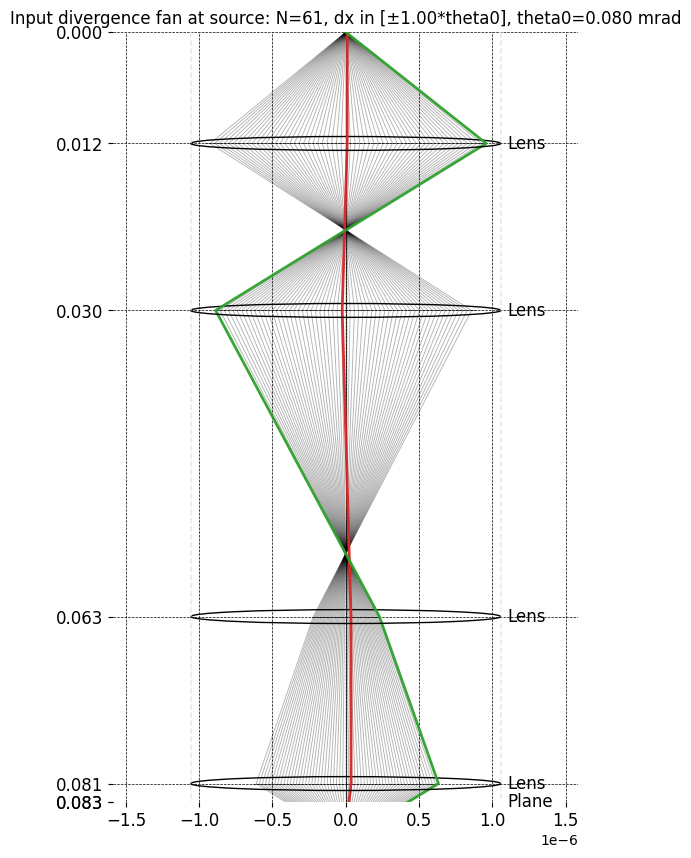

theta0 [mrad]: 0.07983001961973378
fan dx range [mrad]: -0.07983001961973378 to 0.07983001961973378


In [28]:
# Fan controls
fan_num_rays = 61                 # odd count keeps an on-axis ray
fan_divergence_scale = 1.0        # 1.0 -> +/- theta0
fan_band_mode = 'lines'           # 'lines' or 'fill'

# Build the two-ray basis to extract input divergence theta0
source_basis = make_waist_divergence_rays(
    loaded_model['beam']['waist_m'],
    voltage=loaded_model['beam']['voltage_V'],
    z=0.0,
)
source_basis_dx = np.asarray(source_basis.dx, dtype=float).reshape(-1)
theta0_in = float(np.max(np.abs(source_basis_dx)))

# Construct an x-z fan from -theta_max to +theta_max at source
theta_max = fan_divergence_scale * theta0_in
dx_fan = np.linspace(-theta_max, theta_max, int(fan_num_rays), dtype=float)

fan_rays = Ray(
    x=np.zeros_like(dx_fan),
    y=np.zeros_like(dx_fan),
    dx=dx_fan,
    dy=np.zeros_like(dx_fan),
    z=np.zeros_like(dx_fan),
    pathlength=np.zeros_like(dx_fan),
)

fig, ax = plot_model(
    components_realized,
    rays=fan_rays,
    solution_rays=source_basis,
    include_input_rays=True,
    plot_params=legacy_beam_plot_params(),
    band_mode=fan_band_mode,
)
ax.set_title(
    f"Input divergence fan at source: N={fan_num_rays}, "
    f"dx in [\u00b1{fan_divergence_scale:.2f}*theta0], theta0={theta0_in*1e3:.3f} mrad"
)
plt.show()

print('theta0 [mrad]:', theta0_in * 1e3)
print('fan dx range [mrad]:', float(dx_fan.min() * 1e3), 'to', float(dx_fan.max() * 1e3))
